<a href="https://colab.research.google.com/github/mikecrv2019-bit/MAESTRIA-IA/blob/main/MAI540_Modulo%204_Tarea%204.2_Herramienta%20de%20Regresi%C3%B3n%20Auditada/Herramienta_Regresion_CO2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Herramienta de Regresión Auditada — Emisiones de CO₂ de vehículos

**MAI 540 — Machine Learning | Módulo 4 | Tarea 4.2**

La herramienta estima las emisiones de CO₂ (g/km) de una configuración de vehículo ligero a partir de sus especificaciones técnicas. Apoya esta decisión: antes de la homologación oficial, un fabricante o importador decide si la configuración cumple el límite de emisiones de su flota. El error se expresa en **g/km**.

Las reglas de datos (variables prohibidas, partición, subgrupos) están en `context.md`, en esta misma carpeta.

## Decisiones del plan (paso 2)

| Decisión | Valor | Quién la tomó |
|---|---|---|
| Variables prohibidas por fuga | `Fuel Consumption Comb (L/100 km)`, `Comb (mpg)`, `City (L/100 km)`, `Hwy (L/100 km)` | Usuario (Comb y mpg en el paso 1; City y Hwy en el paso 2) |
| Variables excluidas | `Make`, `Model` | Usuario |
| Duplicados exactos | Se eliminan antes de la partición (7.385 → 6.282 filas) | Usuario |
| Partición | 75/25, `random_state=42`, estratificada por `Fuel Type` | Propuesta de Claude, aprobada por el usuario |
| Fila de gas natural (N, 1 fila) | Se conserva y va solo al entrenamiento; en prueba es "no evaluable" | Usuario |
| Imputación | Mediana (numéricas) y moda (categóricas). Hoy no hay nulos; los imputadores protegen ante datos nuevos | Claude |
| Codificación | `OneHotEncoder(handle_unknown="ignore")`; `Transmission` se codifica tal cual (27 valores) | Claude |
| Escalado | `StandardScaler` en las numéricas | Claude |
| Segundo modelo | `RandomForestRegressor(n_estimators=300, random_state=42)`; el resto por defecto, sin ajustar con el conjunto de prueba | Claude |

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from urllib.parse import quote

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

RANDOM_STATE = 42
TARGET = "CO2 Emissions(g/km)"
SUBGRUPO = "Fuel Type"
PROHIBIDAS = [
    "Fuel Consumption Comb (L/100 km)",   # fuga: el CO2 se calcula a partir de este consumo
    "Fuel Consumption Comb (mpg)",        # fuga: la misma medida en otra unidad
    "Fuel Consumption City (L/100 km)",   # fuga: misma prueba de consumo que el CO2
    "Fuel Consumption Hwy (L/100 km)",    # fuga: misma prueba de consumo que el CO2
]
EXCLUIDAS = ["Make", "Model"]
NUMERICAS = ["Engine Size(L)", "Cylinders"]
CATEGORICAS = ["Vehicle Class", "Transmission", "Fuel Type"]

## 1. Carga de datos (solo lectura)

Si el CSV está junto al cuaderno (repositorio clonado), se lee de `data/raw/`. En Google Colab se descarga desde el repositorio en GitHub.

In [2]:
RUTA_LOCAL = Path("data/raw/CO2 Emissions_Canada.csv")
URL_GITHUB = ("https://raw.githubusercontent.com/mikecrv2019-bit/MAESTRIA-IA/main/"
              + quote("MAI540_Modulo 4_Tarea 4.2_Herramienta de Regresión Auditada")
              + "/data/raw/" + quote("CO2 Emissions_Canada.csv"))

fuente = RUTA_LOCAL if RUTA_LOCAL.exists() else URL_GITHUB
df_raw = pd.read_csv(fuente)
print("Fuente:", fuente)
print("Filas y columnas:", df_raw.shape)
assert df_raw.shape == (7385, 12), "El CSV no es el esperado"
df_raw.head()

Fuente: data\raw\CO2 Emissions_Canada.csv
Filas y columnas: (7385, 12)


,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


## 2. Eliminación de duplicados exactos

Se eliminan las filas idénticas en las 12 columnas originales, **antes** de la partición. Así la misma fila no puede quedar a la vez en entrenamiento y en prueba. No es una transformación que estime parámetros: no genera fuga.

In [3]:
df = df_raw.drop_duplicates().reset_index(drop=True)
print("Duplicados exactos eliminados:", len(df_raw) - len(df))
print("Filas restantes:", len(df))
assert len(df) == 6282
df[SUBGRUPO].value_counts()

Duplicados exactos eliminados: 1103
Filas restantes: 6282


Fuel Type
X    3039
Z    2765
E     330
D     147
N       1
Name: count, dtype: int64

## 3. Eliminación de variables prohibidas y excluidas; separación de la objetivo

In [4]:
X = df.drop(columns=PROHIBIDAS + EXCLUIDAS + [TARGET])
y = df[TARGET]

assert not set(PROHIBIDAS + EXCLUIDAS) & set(X.columns), "Quedó una variable prohibida o excluida"
assert set(X.columns) == set(NUMERICAS + CATEGORICAS)
print("Predictoras:", list(X.columns))
print("Nulos en X:", int(X.isna().sum().sum()), "| Nulos en y:", int(y.isna().sum()))

Predictoras: ['Vehicle Class', 'Engine Size(L)', 'Cylinders', 'Transmission', 'Fuel Type']
Nulos en X: 0 | Nulos en y: 0


## 4. Partición entrenamiento / prueba (una sola, para los tres modelos)

Se estratifica por `Fuel Type` con las filas X, Z, E y D. La fila de gas natural (N) no se puede estratificar porque es una sola, así que se agrega solo al entrenamiento.

In [5]:
es_n = X[SUBGRUPO] == "N"
X_train, X_test, y_train, y_test = train_test_split(
    X[~es_n], y[~es_n], test_size=0.25, random_state=RANDOM_STATE, stratify=X.loc[~es_n, SUBGRUPO]
)
X_train = pd.concat([X_train, X[es_n]])
y_train = pd.concat([y_train, y[es_n]])

assert X_train.index.intersection(X_test.index).empty, "Hay filas compartidas entre entrenamiento y prueba"
assert len(X_train) + len(X_test) == len(X)
assert (X_test[SUBGRUPO] != "N").all()
print("Entrenamiento:", X_train.shape, "| Prueba:", X_test.shape)
pd.DataFrame({"entrenamiento": X_train[SUBGRUPO].value_counts(),
              "prueba": X_test[SUBGRUPO].value_counts()}).fillna(0).astype(int)

Entrenamiento: (4711, 5) | Prueba: (1571, 5)


,entrenamiento,prueba
Fuel Type,,
D,110,37
E,248,82
N,1,0
X,2279,760
Z,2073,692


## 5. Preprocesamiento dentro de un Pipeline

Imputación, codificación y escalado viven en un `ColumnTransformer` dentro de cada `Pipeline`. Por eso sus parámetros (medianas, modas, categorías, medias y desviaciones) se estiman solo cuando el pipeline se ajusta con el conjunto de entrenamiento.

In [6]:
def crear_preprocesador():
    numerico = Pipeline([
        ("imputar", SimpleImputer(strategy="median")),
        ("escalar", StandardScaler()),
    ])
    categorico = Pipeline([
        ("imputar", SimpleImputer(strategy="most_frequent")),
        ("codificar", OneHotEncoder(handle_unknown="ignore")),
    ])
    return ColumnTransformer([
        ("num", numerico, NUMERICAS),
        ("cat", categorico, CATEGORICAS),
    ])

## 6. Entrenamiento de los tres modelos

Los tres usan el mismo preprocesamiento y la misma partición:

- **(a) Referencia trivial:** `DummyRegressor` que siempre predice la media del entrenamiento.
- **(b) Regresión lineal.**
- **(c) Random Forest Regressor:** capta interacciones no lineales (por ejemplo, tipo de combustible × cilindrada) que la regresión lineal no representa, y no depende del escalado.

In [7]:
modelos = {
    "Referencia (media)": DummyRegressor(strategy="mean"),
    "Regresión lineal": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
}

pipelines, pred_train, pred_test = {}, {}, {}
for nombre, modelo in modelos.items():
    pipe = Pipeline([("prep", crear_preprocesador()), ("modelo", modelo)])
    pipe.fit(X_train, y_train)          # ajuste SOLO con entrenamiento
    pipelines[nombre] = pipe
    pred_train[nombre] = pipe.predict(X_train)
    pred_test[nombre] = pipe.predict(X_test)  # prueba: solo transformar y predecir
    print(f"{nombre}: entrenado")

Referencia (media): entrenado


Regresión lineal: entrenado


Random Forest: entrenado


### Verificaciones del ajuste sin fuga

In [8]:
# El escalador aprendió la media del ENTRENAMIENTO, no la del dataset completo
escalador = pipelines["Regresión lineal"].named_steps["prep"].named_transformers_["num"].named_steps["escalar"]
assert np.allclose(escalador.mean_, X_train[NUMERICAS].mean().values)
print("Media aprendida por el escalador:", escalador.mean_.round(4))
print("Media del entrenamiento:         ", X_train[NUMERICAS].mean().values.round(4))
print("Media del dataset completo:      ", X[NUMERICAS].mean().values.round(4))

# El modelo de referencia predice siempre la media del entrenamiento
assert np.allclose(pred_test["Referencia (media)"], y_train.mean())
print("Predicción constante de la referencia:", round(y_train.mean(), 2), "g/km")

for nombre in modelos:
    assert len(pred_test[nombre]) == len(y_test)
print("Predicciones de prueba por modelo:", {k: len(v) for k, v in pred_test.items()})

Media aprendida por el escalador: [3.1562 5.6101]
Media del entrenamiento:          [3.1562 5.6101]
Media del dataset completo:       [3.1618 5.6189]
Predicción constante de la referencia: 250.79 g/km
Predicciones de prueba por modelo: {'Referencia (media)': 1571, 'Regresión lineal': 1571, 'Random Forest': 1571}


## 7. Métricas de los tres modelos (paso 3)

MSE, RMSE y R² sobre el **conjunto de prueba**, que se usa aquí por primera vez. El MSE está en (g/km)² y el RMSE en g/km.

In [9]:
from sklearn.metrics import mean_squared_error, r2_score

filas = []
for nombre in modelos:
    mse_te = mean_squared_error(y_test, pred_test[nombre])
    filas.append({
        "Modelo": nombre,
        "MSE prueba (g/km)²": mse_te,
        "RMSE prueba (g/km)": np.sqrt(mse_te),
        "R² prueba": r2_score(y_test, pred_test[nombre]),
        "RMSE entrenamiento (g/km)": np.sqrt(mean_squared_error(y_train, pred_train[nombre])),
        "R² entrenamiento": r2_score(y_train, pred_train[nombre]),
    })
tabla = pd.DataFrame(filas).set_index("Modelo")

# RMSE recalculado a mano desde los residuos, como verificación
for nombre in modelos:
    rmse_manual = np.sqrt(np.mean((y_test.values - pred_test[nombre]) ** 2))
    assert np.isclose(rmse_manual, tabla.loc[nombre, "RMSE prueba (g/km)"])

tabla.round(4)

,MSE prueba (g/km)²,RMSE prueba (g/km),R² prueba,RMSE entrenamiento (g/km),R² entrenamiento
Modelo,,,,,
Referencia (media),3545.1566,59.5412,-0.0006,59.2018,0.0000
Regresión lineal,496.5584,22.2836,0.8598,22.4589,0.8561
Random Forest,236.0910,15.3653,0.9334,12.9844,0.9519


In [10]:
rmse_ref = tabla.loc["Referencia (media)", "RMSE prueba (g/km)"]
comparacion = pd.DataFrame({
    "RMSE prueba (g/km)": tabla["RMSE prueba (g/km)"],
    "Reducción vs referencia (g/km)": rmse_ref - tabla["RMSE prueba (g/km)"],
    "Reducción vs referencia (%)": 100 * (1 - tabla["RMSE prueba (g/km)"] / rmse_ref),
    "R² entrenamiento − R² prueba": tabla["R² entrenamiento"] - tabla["R² prueba"],
})
print("Contexto del conjunto de prueba:")
print(f"  CO2 medio = {y_test.mean():.2f} g/km | desviación estándar = {y_test.std(ddof=0):.2f} g/km")
print(f"  mínimo = {y_test.min()} | máximo = {y_test.max()} g/km")
comparacion.round(4)

Contexto del conjunto de prueba:
  CO2 medio = 252.26 g/km | desviación estándar = 59.52 g/km
  mínimo = 96 | máximo = 522 g/km


,RMSE prueba (g/km),Reducción vs referencia (g/km),Reducción vs referencia (%),R² entrenamiento − R² prueba
Modelo,,,,
Referencia (media),59.5412,0.0000,0.0000,0.0006
Regresión lineal,22.2836,37.2576,62.5745,-0.0038
Random Forest,15.3653,44.1760,74.1939,0.0185


### Interpretación de las métricas

| Modelo | MSE prueba (g/km)² | RMSE prueba (g/km) | R² prueba | R² entrenamiento |
|---|---|---|---|---|
| Referencia (media) | 3.545,16 | 59,54 | −0,0006 | 0,0000 |
| Regresión lineal | 496,56 | 22,28 | 0,8598 | 0,8561 |
| Random Forest | 236,09 | 15,37 | 0,9334 | 0,9519 |

**Qué significa el RMSE en unidades reales.** El mejor modelo, Random Forest, tiene un RMSE de 15,37 g/km. Al estimar el CO₂ de una configuración nueva, el error típico es de unos 15 g/km, sobre un CO₂ medio de 252,26 g/km en prueba (≈ 6,1 %). El RMSE no es un tope: al elevar los errores al cuadrado, pesa más los errores grandes, así que algunos vehículos tendrán desviaciones mayores. Para la decisión de homologación, una configuración cuya estimación quede a menos de unos 15 g/km del límite de la flota no se puede clasificar con seguridad como "cumple" o "no cumple". La regresión lineal tiene un error típico de 22,28 g/km (≈ 8,8 %).

**Qué proporción de la variación explica el R².** Con un R² de prueba de 0,9334, Random Forest explica el 93,3 % de la variación del CO₂ entre vehículos del conjunto de prueba. El 6,7 % restante lo explican factores que no están en las cinco especificaciones usadas (por ejemplo, aerodinámica, peso o tecnología del motor) o que son ruido de la medición. La regresión lineal explica el 86,0 %.

**Por qué no basta con una sola métrica.**
- El R² es relativo y sin unidades: compara el error del modelo con la dispersión del CO₂ en el conjunto de prueba. No dice si 15 g/km es un error aceptable para decidir sobre un límite de emisiones; eso solo lo dice el RMSE, en g/km.
- El RMSE solo, sin referencia, no dice si el modelo aprendió algo. La referencia trivial tiene un RMSE de 59,54 g/km, que parece moderado frente a una media de 252 g/km (≈ 24 %), y sin embargo su R² ≈ 0 muestra que no explica nada: su error es exactamente la dispersión natural del CO₂ (desviación estándar de prueba: 59,52 g/km).
- Un mismo RMSE puede ser excelente en un conjunto muy disperso y malo en uno homogéneo. Un R² alto también puede venir con un RMSE demasiado grande para la decisión. Juntas responden dos preguntas distintas: cuánto se equivoca el modelo (RMSE) y cuánto de la variación captura (R²).

**Mejora frente a la referencia trivial.** La referencia siempre predice 250,79 g/km, la media del entrenamiento. Su R² de prueba es ligeramente negativo (−0,0006) porque la media de prueba (252,26) no coincide exactamente con esa cifra.
- La regresión lineal reduce el RMSE en 37,26 g/km (−62,6 %).
- Random Forest lo reduce en 44,18 g/km (−74,2 %).
- Frente a la regresión lineal, Random Forest baja el error típico 6,92 g/km más (≈ 31 % menos).

**Sobreajuste: R² de entrenamiento frente a prueba.**
- **Regresión lineal:** 0,8561 en entrenamiento y 0,8598 en prueba (diferencia −0,0038; RMSE 22,46 frente a 22,28 g/km). No hay sobreajuste: rinde igual en datos que no vio. Su límite es la capacidad del modelo, que no representa relaciones no lineales, no la memorización.
- **Random Forest:** 0,9519 en entrenamiento y 0,9334 en prueba (diferencia 0,0185; RMSE 12,98 frente a 15,37 g/km). Hay una brecha pequeña: el bosque ajusta algo mejor los datos que vio, pero la caída en prueba es menor de 2 puntos de R², y aun así supera claramente a la regresión lineal en datos no vistos. No se ajustaron hiperparámetros con el conjunto de prueba, así que estas cifras son una estimación no sesgada de su desempeño.

Random Forest es el mejor modelo y es el que se analiza en el paso 4 (residuos).

## 8. Análisis de residuos del mejor modelo: Random Forest (paso 4)

Residuo = CO₂ real − CO₂ predicho, sobre el conjunto de prueba. Un residuo **positivo** significa que el modelo **subestima** las emisiones; uno negativo, que las sobreestima. Las figuras se guardan en `figuras/` para el informe.

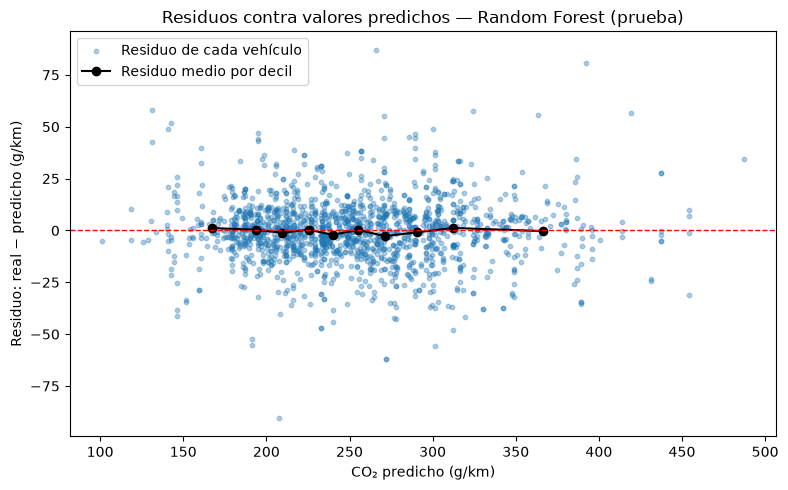

In [11]:
import matplotlib.pyplot as plt

MEJOR = "Random Forest"
pred = pd.Series(pred_test[MEJOR], index=y_test.index, name="predicho")
res = (y_test - pred).rename("residuo")
Path("figuras").mkdir(exist_ok=True)

# Media y desviación de los residuos por decil del valor predicho (línea de tendencia)
decil = pd.qcut(pred, 10)
por_decil = pd.DataFrame({"pred": pred, "res": res}).groupby(decil, observed=True).agg(
    pred_medio=("pred", "mean"), res_medio=("res", "mean"), res_desv=("res", "std"), n=("res", "size"))

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(pred, res, s=10, alpha=0.35, label="Residuo de cada vehículo")
ax.plot(por_decil["pred_medio"], por_decil["res_medio"], "o-", color="black", label="Residuo medio por decil")
ax.axhline(0, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("CO₂ predicho (g/km)")
ax.set_ylabel("Residuo: real − predicho (g/km)")
ax.set_title("Residuos contra valores predichos — Random Forest (prueba)")
ax.legend()
fig.tight_layout()
fig.savefig("figuras/residuos_vs_predichos.png", dpi=150)
plt.show()

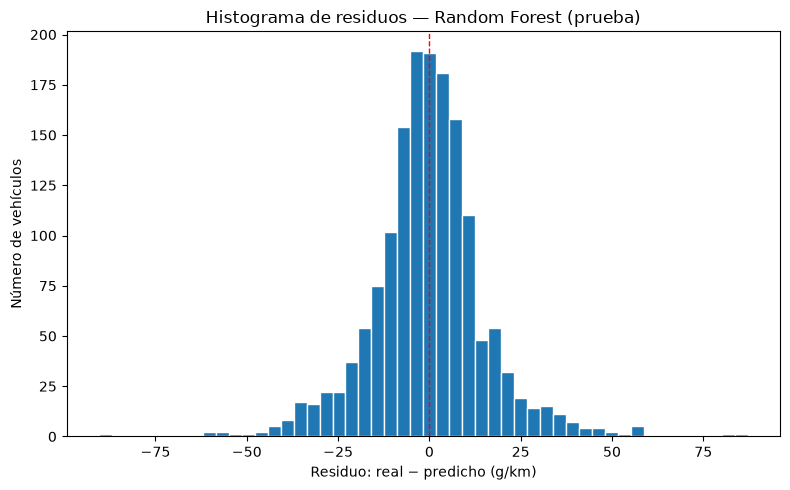

Media = -0.37 | mediana = -0.04 | desviación = 15.37 g/km
Asimetría = 0.10 | curtosis (exceso) = 3.15
|residuo| > 30 g/km: 108 vehículos (6.9 %)
Percentiles 1, 5, 95 y 99: {0.01: -38.2, 0.05: -26.1, 0.95: 23.9, 0.99: 43.2}


In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(res, bins=50, edgecolor="white")
ax.axvline(0, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Residuo: real − predicho (g/km)")
ax.set_ylabel("Número de vehículos")
ax.set_title("Histograma de residuos — Random Forest (prueba)")
fig.tight_layout()
fig.savefig("figuras/histograma_residuos.png", dpi=150)
plt.show()

print(f"Media = {res.mean():.2f} | mediana = {res.median():.2f} | desviación = {res.std():.2f} g/km")
print(f"Asimetría = {res.skew():.2f} | curtosis (exceso) = {res.kurt():.2f}")
print(f"|residuo| > 30 g/km: {(res.abs() > 30).sum()} vehículos ({100 * (res.abs() > 30).mean():.1f} %)")
print("Percentiles 1, 5, 95 y 99:", res.quantile([.01, .05, .95, .99]).round(1).to_dict())

### Evidencia numérica: curvatura y dispersión por decil del valor predicho

In [13]:
por_decil.round(2)

,pred_medio,res_medio,res_desv,n
predicho,,,,
"(100.96499999999999, 186.28]",167.27,1.17,15.17,164
"(186.28, 201.012]",193.71,0.36,13.66,151
"(201.012, 216.097]",209.60,-1.12,14.61,161
"(216.097, 233.264]",225.34,0.35,14.66,162
"(233.264, 248.373]",239.91,-2.07,11.84,152
"(248.373, 262.403]",255.34,0.22,13.04,154
"(262.403, 278.796]",271.37,-2.72,18.62,156
"(278.796, 300.132]",290.70,-0.89,15.81,159
"(300.132, 326.647]",312.34,1.22,17.28,161


### Evidencia numérica: ¿hay grupos con residuos sistemáticamente positivos o negativos?

In [14]:
def resumen_por(columna):
    g = pd.DataFrame({"res": res, columna: X_test[columna]}).groupby(columna)["res"]
    t = pd.DataFrame({"n": g.size(), "residuo_medio": g.mean(), "residuo_mediano": g.median(),
                      "RMSE": g.apply(lambda r: np.sqrt(np.mean(r ** 2)))})
    # t = media / error estándar: |t| > 2 indica un sesgo difícil de atribuir al azar
    t["t"] = t["residuo_medio"] / (g.std() / np.sqrt(g.size()))
    return t.sort_values("residuo_medio")

print("Por tipo de combustible:")
display(resumen_por("Fuel Type").round(2))
print("Por clase de vehículo:")
display(resumen_por("Vehicle Class").round(2))

Por tipo de combustible:


,n,residuo_medio,residuo_mediano,RMSE,t
Fuel Type,,,,,
D,37,-2.86,-3.46,19.06,-0.91
E,82,-1.85,-1.51,11.80,-1.43
Z,692,-0.65,-0.12,15.64,-1.09
X,760,0.17,0.24,15.25,0.31


Por clase de vehículo:


,n,residuo_medio,residuo_mediano,RMSE,t
Vehicle Class,,,,,
MINIVAN,14,-5.60,-5.95,10.32,-2.33
SPECIAL PURPOSE VEHICLE,18,-2.40,-2.68,7.04,-1.50
SUV - SMALL,266,-1.92,-1.91,16.87,-1.86
MINICOMPACT,72,-1.66,-2.74,10.78,-1.31
FULL-SIZE,115,-1.59,-0.15,15.31,-1.11
VAN - CARGO,6,-1.18,2.11,6.39,-0.42
COMPACT,209,-1.01,-1.22,13.86,-1.05
SUBCOMPACT,133,-0.32,0.30,13.25,-0.28
PICKUP TRUCK - STANDARD,132,-0.26,1.35,15.25,-0.20


In [15]:
# Los 10 residuos más grandes en valor absoluto (solo especificaciones, sin Make/Model)
extremos = X_test.assign(real=y_test, predicho=pred.round(1), residuo=res.round(1)) \
    .reindex(res.abs().sort_values(ascending=False).index).head(10)
extremos

,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,real,predicho,residuo
6070,FULL-SIZE,2.0,4,AM6,X,117,207.4,-90.4
3790,SUV - SMALL,3.0,6,A9,Z,353,265.9,87.1
4583,SUV - STANDARD,6.0,12,A7,Z,473,392.4,80.6
4788,SUV - SMALL,3.0,6,AM7,Z,210,271.7,-61.7
3104,SUV - SMALL,3.0,6,AM7,Z,210,271.7,-61.7
5905,MID-SIZE,1.5,4,AV,X,189,131.1,57.9
193,COMPACT,6.2,8,AS6,Z,382,324.4,57.6
2762,SUV - STANDARD,6.0,12,AS7,Z,476,419.4,56.6
1100,MID-SIZE,4.0,8,AS8,Z,246,301.6,-55.6
4582,SUV - STANDARD,5.5,8,A7,Z,419,363.5,55.5


### Diagnóstico: ¿qué estructura deja de capturar el modelo?

`Make` y `Model` están **excluidas del modelo**. Aquí solo se consultan, para buscar qué tienen en común los vehículos con residuos grandes. Los nombres comerciales indican tecnologías que las cinco especificaciones no registran: híbrido (`HYBRID`) y tracción integral (`AWD`, `4WD`, `4X4`).

In [16]:
modelo_comercial = df.loc[y_test.index, "Model"].str.upper()
filas_tec = []
for etiqueta in ["HYBRID", "AWD", "4WD", "4X4"]:
    tiene = modelo_comercial.str.contains(etiqueta, regex=False)
    r = res[tiene]
    filas_tec.append({"En el nombre del modelo": etiqueta, "n (prueba)": int(tiene.sum()),
                      "residuo_medio": r.mean(), "residuo_mediano": r.median(),
                      "t": r.mean() / (r.std() / np.sqrt(len(r))),
                      "residuo_medio del resto": res[~tiene].mean()})
display(pd.DataFrame(filas_tec).set_index("En el nombre del modelo").round(2))
print("Los 10 residuos más grandes, con su nombre comercial:")
display(df.loc[extremos.index, ["Make", "Model"]].join(extremos[["real", "predicho", "residuo"]]))

,n (prueba),residuo_medio,residuo_mediano,t,residuo_medio del resto
En el nombre del modelo,,,,,
HYBRID,30,-24.15,-21.14,-5.98,0.10
AWD,241,4.33,5.38,4.80,-1.22
4WD,104,5.16,5.35,3.41,-0.76
4X4,74,8.00,8.24,5.08,-0.78


Los 10 residuos más grandes, con su nombre comercial:


,Make,Model,real,predicho,residuo
6070,HYUNDAI,Sonata Hybrid,117,207.4,-90.4
3790,MERCEDES-BENZ,AMG GLC 43 4MATIC COUPE,353,265.9,87.1
4583,MERCEDES-BENZ,AMG G 65,473,392.4,80.6
4788,ACURA,MDX Hybrid AWD,210,271.7,-61.7
3104,ACURA,MDX HYBRID AWD,210,271.7,-61.7
5905,CHEVROLET,Malibu,189,131.1,57.9
193,CHEVROLET,CAMARO ZL1,382,324.4,57.6
2762,MERCEDES-BENZ,AMG G 65,476,419.4,56.6
1100,AUDI,A8,246,301.6,-55.6
4582,MERCEDES-BENZ,AMG G 63,419,363.5,55.5


In [17]:
# Vehículos distintos con las MISMAS cinco especificaciones: el modelo solo puede darles una predicción
combos = df.groupby(NUMERICAS + CATEGORICAS)[TARGET]
tam = combos.transform("size")
desvio = df[TARGET] - combos.transform("mean")
print(f"Combinaciones distintas de las 5 especificaciones: {combos.ngroups} (para {len(df)} filas)")
print(f"Filas que comparten combinación con otra fila: {(tam > 1).sum()}")
print(f"RMSE del CO2 alrededor de la media de su combinación: {np.sqrt(np.mean(desvio[tam > 1] ** 2)):.2f} g/km")

Combinaciones distintas de las 5 especificaciones: 964 (para 6282 filas)
Filas que comparten combinación con otra fila: 6102
RMSE del CO2 alrededor de la media de su combinación: 13.16 g/km


### Interpretación de los residuos

**1. Curvatura: no hay.** El residuo medio por decil del valor predicho va de −2,72 a +1,22 g/km, sin tendencia: sube y baja alrededor de cero en todo el rango (de 167 a 366 g/km predichos). Estas oscilaciones son pequeñas frente al RMSE de 15,37 g/km. En la gráfica, la línea negra se mantiene pegada a la línea roja del cero. El modelo no subestima sistemáticamente los extremos ni sobreestima el centro.

**2. Dispersión que crece con el valor predicho: leve.** La desviación de los residuos es de 11,84 a 15,17 g/km en los seis primeros deciles (promedio ≈ 13,8) y de 15,81 a 18,62 en los cuatro últimos (promedio ≈ 17,3). Los vehículos de mayores emisiones se estiman con algo menos de precisión, pero el aumento es moderado y no es un embudo marcado. La mayor desviación está en el séptimo decil (≈ 271 g/km predichos), no en el último.

**3. Forma del histograma.** Está centrado en cero (media −0,37; mediana −0,04 g/km) y es casi simétrico (asimetría 0,10): el modelo no tiene un sesgo global. Pero tiene colas más pesadas que una normal (curtosis en exceso 3,15). La mayoría de los errores son pequeños, pero 108 vehículos (6,9 %) tienen un error mayor de 30 g/km, y los extremos llegan a −90 y +87 g/km.

**4. Grupos con residuos sistemáticos.**
- **Por tipo de combustible no hay sesgo:** todos los |t| son menores de 1,5. Diésel (D) tiene el RMSE más alto (19,06 g/km), pero con solo 37 vehículos en prueba. Etanol (E) tiene el más bajo (11,80).
- **Por clase de vehículo**, solo MINIVAN supera |t| = 2 (−5,60 g/km, t = −2,33), con apenas 14 vehículos. Con 16 clases comparadas, un valor así en un grupo tan pequeño puede aparecer por azar, así que no lo trato como patrón confirmado.
- **Los grupos claramente sistemáticos aparecen al mirar tecnologías que no están entre las predictoras:**
  - **Híbridos** (30 en prueba): residuo medio −24,15 g/km (t = −5,98). El modelo **sobreestima** su CO₂ en unos 24 g/km, porque para él un híbrido es igual que un vehículo convencional con el mismo motor. El caso extremo es el Hyundai Sonata Hybrid: real 117, predicho 207 g/km.
  - **Tracción integral** en el nombre del modelo: AWD +4,33 (t = 4,80), 4WD +5,16 (t = 3,41) y 4X4 +8,00 (t = 5,08). El modelo **subestima** a estos vehículos.
  - **Alto desempeño:** 5 de los 10 mayores errores son versiones deportivas (Mercedes-AMG, Camaro ZL1); en 4 de ellos el modelo subestima entre 55 y 87 g/km. Esto se observa en los extremos, pero no está cuantificado como grupo.

**5. Qué estructura de los datos deja de capturar el modelo.** Las cinco especificaciones permitidas (clase, cilindrada, cilindros, transmisión y combustible) no describen:
- la **tecnología de propulsión**: híbrido o no;
- la **tracción**: 2 ruedas o integral;
- el **enfoque de desempeño** del motor.

Además hay un límite de información: las 6.282 filas se reducen a solo 964 combinaciones distintas de esas especificaciones, y 6.102 filas comparten combinación con otra. Vehículos con especificaciones idénticas tienen CO₂ distinto: alrededor de la media de su combinación, el CO₂ varía con un RMSE de 13,16 g/km. Esta cifra es descriptiva (calculada sobre todo el dataset) y aproxima el error mínimo que cualquier modelo con estas cinco variables tendría en datos nuevos. El RMSE de prueba de Random Forest (15,37 g/km) está cerca de ese piso. Por eso la mayor parte del error restante se debe a la información que falta, no a la forma del modelo. Para bajar el error habría que agregar variables como "híbrido" o "tracción".

**Observación de calidad de datos.** Entre los 10 mayores residuos aparecen dos filas del mismo vehículo, "MDX Hybrid AWD" y "MDX HYBRID AWD": mismas especificaciones y mismo CO₂, pero el nombre escrito con distinta capitalización. `drop_duplicates()` no las detectó como duplicadas, y ambas quedaron en prueba.

**Limitación del diagnóstico.** La tracción se detectó buscando `AWD`, `4WD` y `4X4` en el nombre comercial. Otras denominaciones de marca (por ejemplo, `4MATIC`) no se contaron, así que los recuentos de tracción integral son un mínimo.